<a href="https://colab.research.google.com/github/Nadaramadan1/Assignment_Week-2/blob/main/Document%20Scanner%20Preprocessing%20Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
# ==========================================
# Document Scanner Preprocessing Pipeline
# Author:Nada Ramadan
# Purpose: Convert scanned images into clean OCR-ready documents
# ==========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import files



In [41]:
# ==========================================
# 1. Upload Images (Batch Input)
# ==========================================
images = {}

uploaded = files.upload()

for filename in uploaded.keys():
    img = cv2.imdecode(
        np.frombuffer(uploaded[filename], np.uint8),
        cv2.IMREAD_COLOR
    )
    images[filename] = img

print(f"\n Uploaded {len(images)} images successfully\n")




Saving Handwritten-Document.jpg to Handwritten-Document.jpg

 Uploaded 1 images successfully



In [42]:
# ==========================================
# 2. Preprocessing Pipeline Function
# ==========================================
def preprocess(img, block_size=9, c_value=3, kernel_size=(1,1), iterations=3):

    # 1. Convert to Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. CLAHE (Contrast Enhancement)
    # improves local contrast in uneven lighting
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)

    # 3. Gaussian Blur (Noise Removal)
    blurred = cv2.bilateralFilter(enhanced, 9, 75, 75)

    # 4. Adaptive Thresholding
    # handles different lighting conditions across image
    thresh = cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    block_size,
    c_value
)

    # 5. Morphological Cleaning
    # Opening: remove small noise
    # Closing: fill small holes in text
    kernel = np.ones(kernel_size, np.uint8)

    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=iterations)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel, iterations=iterations)

    return gray, cleaned




In [43]:
# ==========================================
# 3. Output Folder
# ==========================================
output_dir = "clean_outputs"
os.makedirs(output_dir, exist_ok=True)




In [44]:
# ==========================================
# 4. Process All Images
# ==========================================
for name, img in images.items():

    gray, final = preprocess(img)

    # Save final output
    output_path = os.path.join(output_dir, "clean_" + name)
    cv2.imwrite(output_path, final)



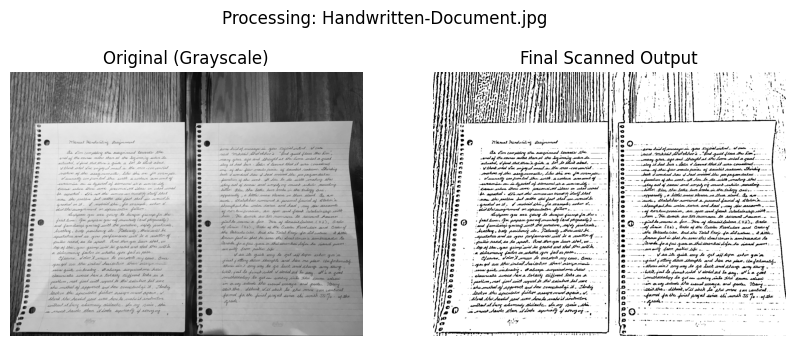


 All images processed and saved successfully


In [45]:
# ======================================
# Visualization (Before vs After)
# ======================================
plt.figure(figsize=(10,4))
plt.suptitle(f"Processing: {name}")

# Original (Gray)
plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original (Grayscale)")
plt.axis("off")

# Final Output
plt.subplot(1,2,2)
plt.imshow(final, cmap='gray')
plt.title("Final Scanned Output")
plt.axis("off")

plt.show()

print("\n All images processed and saved successfully")